/tmp/ipykernel_71321/2391915823.py:106: RuntimeWarning: divide by zero encountered in log10
  log_lv_data = np.log10(lv_data)
/tmp/ipykernel_71321/2391915823.py:106: RuntimeWarning: invalid value encountered in log10
  log_lv_data = np.log10(lv_data)


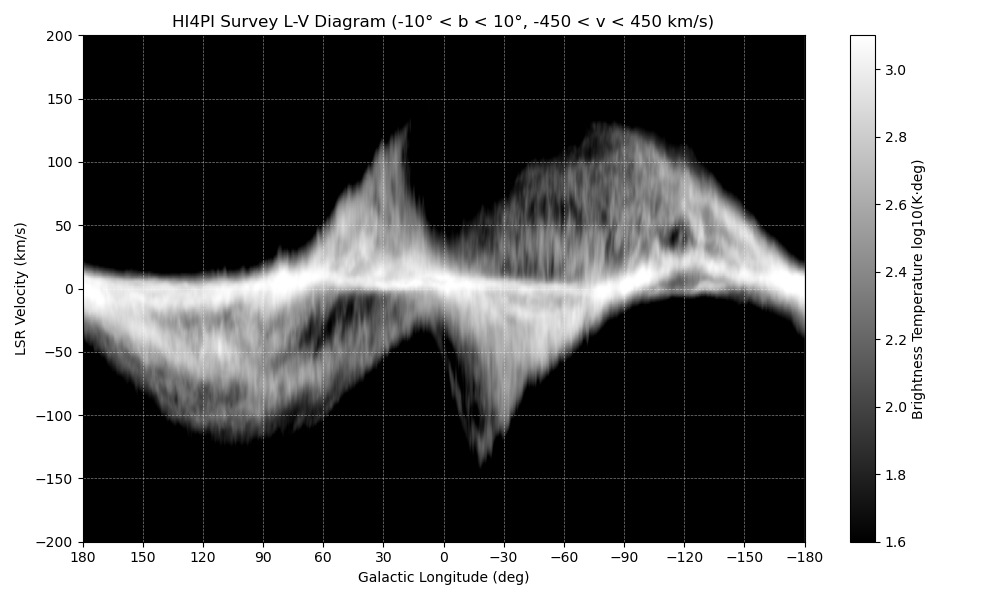

In [2]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm
%matplotlib widget

# input and output file names
input_file = 'HI4PI_ALLSKY_GAL_CAR.fits'
output_file = 'HI4PI_Galactic_LV.fits'

with fits.open(input_file) as hdul:
    data = hdul[0].data
    header = hdul[0].header

    nvel = header['NAXIS3']
    nlat = header['NAXIS2']
    nlon = header['NAXIS1']

    # Galactic longitude
    crval_lon = header['CRVAL1']
    crpix_lon = header['CRPIX1']
    cdelt_lon = header['CDELT1']

    # Galactic latitude
    crval_lat = header['CRVAL2']
    crpix_lat = header['CRPIX2']
    cdelt_lat = header['CDELT2']

    # Velocity
    crval_vel = header['CRVAL3']
    crpix_vel = header['CRPIX3']
    cdelt_vel = header['CDELT3']

# Calculate the Galactic latitude values for each pixel
lat_pixels = np.arange(1, nlat + 1)
lat_values = crval_lat + (lat_pixels - crpix_lat) * cdelt_lat

# Calculate the velocity values for each pixel (converted to km/s)
vel_pixels = np.arange(1, nvel + 1)
vel_values = (crval_vel + (vel_pixels - crpix_vel) * cdelt_vel) / 1000.0  # m/s -> km/s

# Find pixel range for -10 < b < 10 degrees
lat_mask = (lat_values >= -10.0) & (lat_values <= 10.0)
lat_indices = np.where(lat_mask)[0]

# Find pixel range for -450 < v < 450 km/s
vel_mask = (vel_values >= -450.0) & (vel_values <= 450.0)
vel_indices = np.where(vel_mask)[0]

# Extract subsets for velocity and Galactic latitude
data_subset = data[vel_indices, :, :]  # extract velocity range
data_subset = data_subset[:, lat_indices, :]  # extract Galactic latitude range

# Integrate over Galactic latitude
lv_data = np.nansum(data_subset, axis=1) * abs(cdelt_lat)

# Calculate new velocity axis parameters (only including ±300 km/s part)
new_nvel = len(vel_indices)
new_crpix_vel = 1.0
new_crval_vel = vel_values[vel_indices[0]] * 1000.0  # convert back to m/s
new_cdelt_vel = cdelt_vel

# Create new FITS header - use linear coordinates for ds9 compatibility
new_header = fits.Header()
new_header['SIMPLE'] = True
new_header['BITPIX'] = -32
new_header['NAXIS'] = 2
new_header['NAXIS1'] = nlon
new_header['NAXIS2'] = new_nvel

# Galactic longitude axis - using linear coordinates
new_header['CTYPE1'] = 'LINEAR'
new_header['CRVAL1'] = crval_lon
new_header['CRPIX1'] = crpix_lon
new_header['CDELT1'] = cdelt_lon
new_header['CUNIT1'] = 'deg'
new_header['CNAME1'] = 'Galactic Longitude'

# Velocity axis - using linear coordinates, units in km/s
new_header['CTYPE2'] = 'LINEAR'
new_header['CRVAL2'] = new_crval_vel / 1000.0  # convert to km/s
new_header['CRPIX2'] = new_crpix_vel
new_header['CDELT2'] = new_cdelt_vel / 1000.0  # convert to km/s
new_header['CUNIT2'] = 'km/s'
new_header['CNAME2'] = 'LSR Velocity'

# Other information
new_header['BUNIT'] = 'K deg'
new_header['OBJECT'] = 'HI4PI Survey L-V Diagram'
new_header['COMMENT'] = 'Integrated over -10 < GLAT < 10 deg'
new_header['COMMENT'] = 'Velocity range: -450 to +450 km/s'
new_header['COMMENT'] = 'Axis 1: Galactic Longitude (deg)'
new_header['COMMENT'] = 'Axis 2: LSR Velocity (km/s)'
new_header['BLATMIN'] = -10.0
new_header['BLATMAX'] = 10.0
new_header['VELMIN'] = -450.0
new_header['VELMAX'] = 450.0
if 'RESTFREQ' in header:
    new_header['RESTFREQ'] = header['RESTFREQ']

# Save as FITS file
hdu = fits.PrimaryHDU(data=lv_data, header=new_header)
hdu.writeto(output_file, overwrite=True)

# Plot preview
log_lv_data = np.log10(lv_data)
log_lv_data[np.isnan(log_lv_data)] = 0  # Replace -inf with 0 for plotting

fig, ax = plt.subplots(figsize=(10, 6))

lon_pixels = np.arange(1, nlon + 1)
lon_values = crval_lon + (lon_pixels - crpix_lon) * cdelt_lon

# Use the trimmed velocity values for plotting
vel_plot = vel_values[vel_indices]

im = ax.imshow(log_lv_data, aspect='auto', origin='lower',
               extent=[lon_values.max(), lon_values.min(),
                      vel_plot.min(), vel_plot.max()],
               cmap='gray', norm=PowerNorm(gamma=1, vmin=1.6, vmax=3.1))

ax.set_xlabel('Galactic Longitude (deg)')
ax.set_ylabel('LSR Velocity (km/s)')
ax.set_title('HI4PI Survey L-V Diagram (-10° < b < 10°, -450 < v < 450 km/s)')
# Add grid
ax.set_xlim(180, -180)
ax.set_ylim(-200, 200)
ax.set_xticks(np.arange(-180, 181, 30))
ax.set_yticks(np.arange(-200, 201, 50))
ax.grid(True, alpha=0.5, linestyle='--', color='white', linewidth=0.5)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Brightness Temperature log10(K·deg)')

plt.tight_layout()
plt.savefig('HI4PI_Galactic_LV.png', dpi=300)
plt.show()